Zadanie 11

Stwórz nowe zmienne z Titanic:
- FamilySize = SibSp + Parch + 1
- IsAlone = 1 jeśli FamilySize == 1, inaczej 0
- AgeGroup = kategorie (0-12, 13-18, 19-35, 36-60, 60+)

Wymagania:
- Dodaj wszystkie 3 zmienne do DataFrame
- Wyświetl value_counts() dla każdej
- Oblicz wskaźnik przeżycia dla IsAlone vs nie alone

Rozmiar rodziny:
FamilySize
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

Pasażerowie samotni: 537
IsAlone
1    537
0    354
Name: count, dtype: int64

Grupy wiekowe:
AgeGroup
19 - 35    358
36 - 60    195
13 - 18     70
0 - 12      69
60+         22
Name: count, dtype: int64

10 pierwszych wierszy z nowymi zmiennymi:
                                                Name   Age AgeGroup  \
0                            Braund, Mr. Owen Harris  22.0  19 - 35   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0  36 - 60   
2                             Heikkinen, Miss. Laina  26.0  19 - 35   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0  19 - 35   
4                           Allen, Mr. William Henry  35.0  19 - 35   
5                                   Moran, Mr. James   NaN      NaN   
6                            McCarthy, Mr. Timothy J  54.0  36 - 60   
7                     Palsson, Master. Go

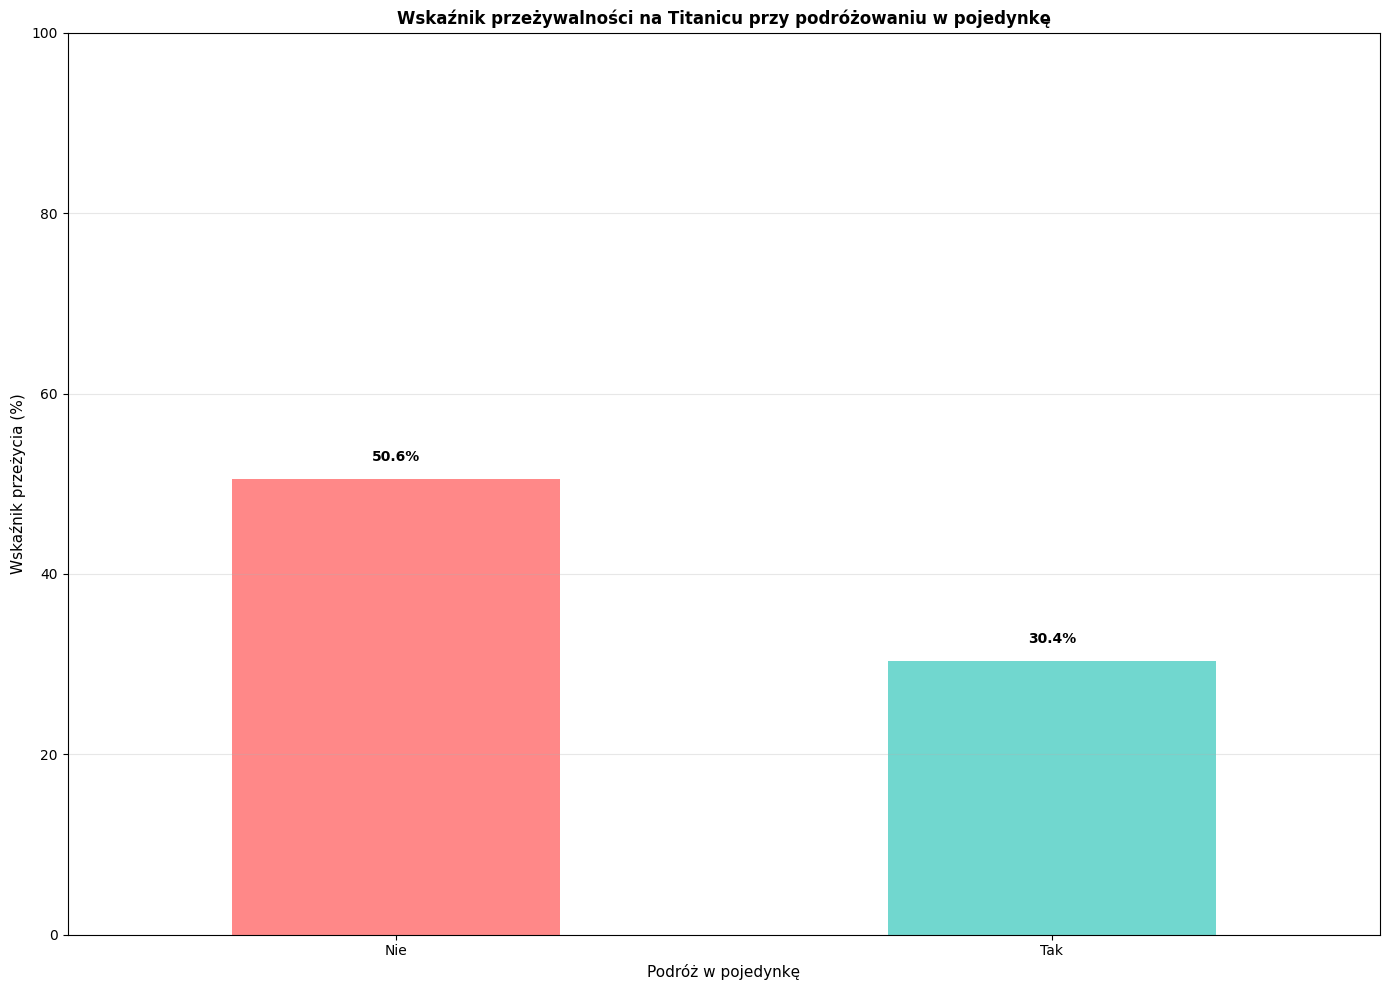

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic = pd.read_csv(url)

titanic_featured = titanic.copy()

# Feature 1: Rozmiar rodziny
titanic_featured['FamilySize'] = titanic_featured['SibSp'] + titanic_featured['Parch'] + 1
print("Rozmiar rodziny:")
print(titanic_featured['FamilySize'].value_counts())

# Feature 2: Czy pasażer był sam?
titanic_featured['IsAlone'] = (titanic_featured['FamilySize'] == 1).astype(int)
print(f"\nPasażerowie samotni: {titanic_featured['IsAlone'].sum()}")
print(titanic_featured['IsAlone'].value_counts())

# Feature 3: Kategoria wiekowa
bins_ = [0, 12, 18, 35, 60, 100]
labels_ = ['0 - 12', '13 - 18', '19 - 35', '36 - 60', '60+']
titanic_featured['AgeGroup'] = pd.cut(titanic_featured['Age'], bins=bins_, labels=labels_)
print("\nGrupy wiekowe:")
print(titanic_featured['AgeGroup'].value_counts())

# Przykładowe wiersze z nowymi zmiennymi
print("\n10 pierwszych wierszy z nowymi zmiennymi:")
print(titanic_featured[['Name', 'Age', 'AgeGroup', 'FamilySize', 'IsAlone']].head(10))

# Wskaźniki przeżycia dla IsAlone vs nie alone
survival_by_isalone = titanic_featured.groupby('IsAlone')['Survived'].mean() * 100
print("\nWskaźniki przeżycia [%]:")
print(survival_by_isalone)

# Wizualizacja
fig, ax = plt.subplots(figsize=(14, 10))

survival_by_isalone.plot(kind='bar', ax=ax, color=['#ff6b6b','#4ecdc4'], alpha=0.8)
ax.set_ylabel('Wskaźnik przeżycia (%)', fontsize=11)
ax.set_xlabel('Podróż w pojedynkę', fontsize=11)
ax.set_title('Wskaźnik przeżywalności na Titanicu przy podróżowaniu w pojedynkę', fontsize=12, fontweight='bold')
ax.set_xticklabels(['Nie', 'Tak'], rotation=0)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

for i, v in enumerate(survival_by_isalone.values):
    ax.text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()